In [ ]:
# Import required packages and set up the environment
import scanpy as sc
import omicverse as ov
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set up plotting parameters
ov.plot_set(font_path='Arial')

# Enable auto-reload for development
%load_ext autoreload
%autoreload 2

In [ ]:
adata = sc.read("../data/adata_CD4T_adata.h5ad")
adata

In [ ]:
adata_magic = adata.raw.to_adata().copy()
adata_magic.X = adata_magic.uns['magic_imputed_data_CD4T']
adata_magic

In [ ]:
%matplotlib inline
ov.utils.embedding(adata_magic,
                basis='X_diffmap',frameon='small',wspace=0.5,
                color=['TBX21', 'CD4T_celltype',],show=False)
plt.savefig('./results_CD4T/1.TBX21_expression_magic.pdf', dpi=600, bbox_inches = "tight")
plt.show()

In [ ]:
adata.X.max()

In [ ]:
adata.layers['counts'].max()

In [ ]:
# Display basic information about the dataset
print("Dataset shape:", adata.shape)
print("Cell types available:", adata.obs['CD4T_celltype'].unique())

In [ ]:
# Set paths to the required database files
# Update these paths to match your local installation
db_glob = "/home/a3v2s01009/data/s01009/method_test/SCENIC/scenic/databases/hg38/*feather"
motif_path = "/home/a3v2s01009/data/s01009/method_test/SCENIC/scenic/motif/hg38/motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl"

# The db_glob pattern should match both ranking database files
# The motif_path should point to the TF-motif annotation file

In [ ]:
# Verify that the database files exist
!ls /home/a3v2s01009/data/s01009/method_test/SCENIC/scenic/databases/hg38/*feather

# Check the motif annotation file
!ls /home/a3v2s01009/data/s01009/method_test/SCENIC/scenic/motif/hg38/motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl

In [ ]:
import numpy as np
from scipy import sparse

counts = adata.layers['counts']
if sparse.issparse(counts):
    mean = np.array(counts.mean(axis=0)).flatten()
    mean_sq = np.array(counts.power(2).mean(axis=0)).flatten()
    var = mean_sq - mean ** 2
else:
    var = counts.var(axis=0)

valid_gene_idx = np.where(var > 0)[0]
adata = adata[:, valid_gene_idx].copy()

In [ ]:
# Initialize the SCENIC object
scenic_obj = ov.single.SCENIC(
    adata=adata,                    # Single-cell expression data
    db_glob=db_glob,                # Pattern for ranking database files
    motif_path=motif_path,          # TF-motif annotation file
    n_jobs=10                       # Number of parallel processes
)

In [ ]:
# Perform GRN inference
edgelist = scenic_obj.cal_grn(layer='counts')
edgelist.head(10)

In [ ]:
# Perform regulon inference and AUCell scoring
regulon_ad = scenic_obj.cal_regulons(
    rho_mask_dropouts=False,          # Mask dropout events
    thresholds=(0.5, 0.75),          # Motif enrichment thresholds
    top_n_targets=(200,),             # Max targets per regulon
    top_n_regulators=(10, 50)     # Max regulators to consider
)

In [ ]:
# Display the first few rows and columns
scenic_obj.auc_mtx.head()

In [ ]:
# Examine the structure of individual regulons
print("Detailed regulon structure:")
print(f"Total regulons: {len(scenic_obj.regulons)}")

# Look at first two regulons in detail
for i, regulon in enumerate(scenic_obj.regulons[:2]):
    print(f"\n--- Regulon {i+1}: {regulon.name} ---")
    print(f"Transcription Factor: {regulon.transcription_factor}")
    print(f"Number of target genes: {len(regulon.genes)}")
    print(f"Target genes: {list(regulon.genes)}")
    print(f"Context: {regulon.context}")
    print(f"Score: {regulon.score:.3f}")
    if regulon.gene2weight:
        print(f"Gene weights (first 3): {dict(list(regulon.gene2weight.items())[:3])}")


In [ ]:
# Prepare the regulon AnnData object for downstream analysis
# Copy the spatial coordinates from the original data
regulon_ad.obsm = adata[regulon_ad.obs.index].obsm.copy()
regulon_ad

In [ ]:
import pandas as pd
all_data = []

for regulon in scenic_obj.regulons:
    try:
        name = regulon.name
        gene_dict = dict(regulon.gene2weight)
        for gene, weight in gene_dict.items():
            all_data.append({
                'regulon_name': name,
                'gene': gene,
                'weight': weight
            })
    except Exception as e:
        print(f"处理 Regulon 时出错: {e}")
        continue

df = pd.DataFrame(all_data)
print(df)

In [ ]:
df.to_csv("results_CD4T/regulon_CD4T.csv")

In [ ]:
# Import required modules for RSS analysis
from omicverse.externel.pyscenic.rss import regulon_specificity_scores
from omicverse.externel.pyscenic.plotting import plot_rss
from adjustText import adjust_text

### Calculate RSS Values

RSS calculation compares regulon activity distributions across cell types using Jensen-Shannon divergence.

In [ ]:
# Calculate Regulon Specificity Scores (RSS)
print("Calculating RSS for all regulons across cell types...")

# Calculate RSS using the AUCell matrix and cell type annotations
rss = regulon_specificity_scores(
    scenic_obj.auc_mtx,                    # AUCell activity matrix
    scenic_obj.adata.obs['CD4T_celltype']  # Cell type annotations
)

print(f"RSS matrix shape: {rss.shape}")
print(f"Cell types: {list(rss.index)}")
print(f"Number of regulons: {len(rss.columns)}")
print(f"RSS value range: {rss.min().min():.3f} - {rss.max().max():.3f}")

# Display the RSS matrix
print("\nRSS matrix (first 5 regulons):")
rss.head()

In [ ]:
rss.to_csv("results_CD4T/rss_CD4T.csv")

### RSS Visualization: Cell-Type-Specific Regulons

This comprehensive plot shows the **top 5 most specific regulons** for each cell type. The visualization helps identify:

- **Master regulators**: TFs with highest RSS for each cell type
- **Regulatory signatures**: Cell-type-specific TF programs
- **Developmental patterns**: TF specificity across the hematopoietic hierarchy

**Interpretation Guide**:
- **Y-axis**: RSS score (higher = more specific)
- **Labels**: Top 5 regulons for each cell type
- **Colors**: Different cell types
- **Patterns**: Notice which TFs are specific vs. broadly active

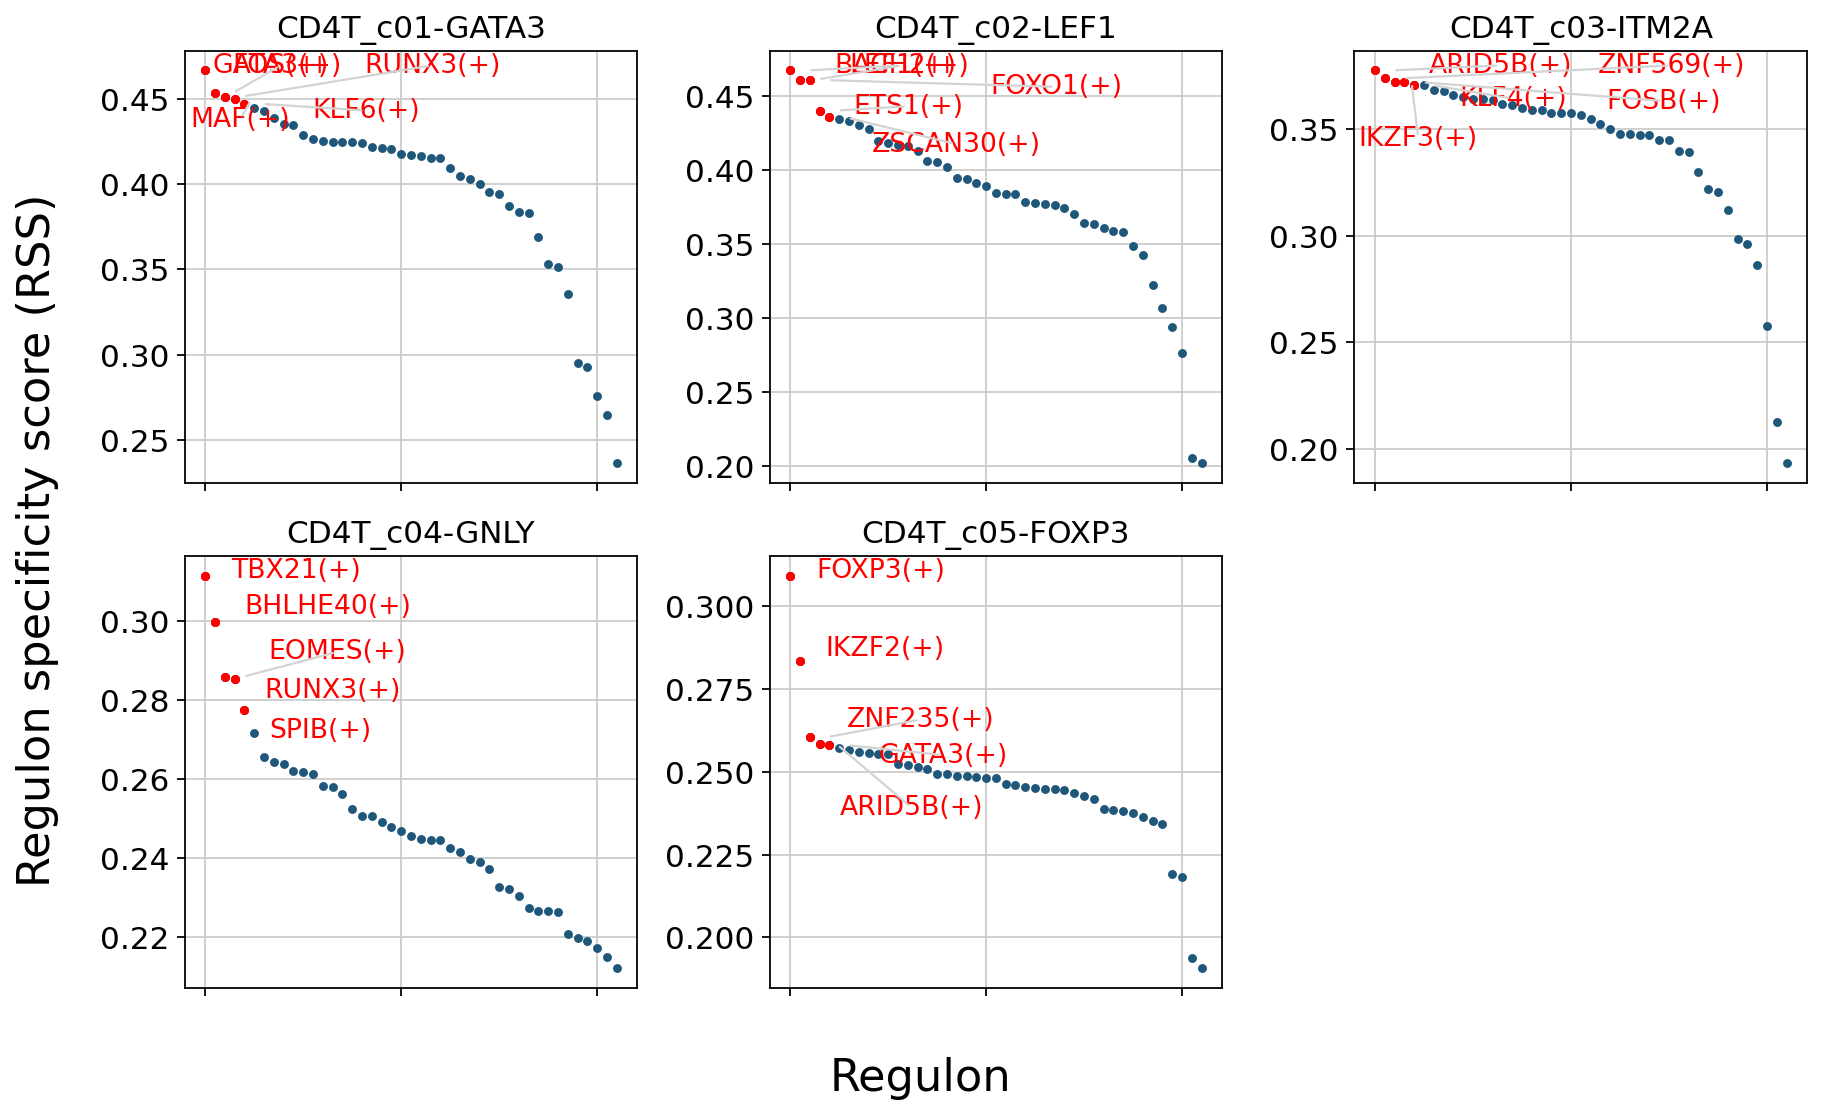

In [11]:
import math

cats = sorted(list(set(adata.obs['CD4T_celltype'])))
n_cats = len(cats)

n_cols = 3  
n_rows = math.ceil(n_cats / n_cols) 

fig = ov.plt.figure(figsize=(11.5, 3.5 * n_rows)) 

for c, num in zip(cats, range(1, n_cats + 1)):
    x = rss.T[c]
    ax = fig.add_subplot(n_rows, n_cols, num) 
    plot_rss(rss, c, top_n=5, max_n=None, ax=ax)
    ax.set_ylim(x.min() - (x.max() - x.min()) * 0.05, 
                x.max() + (x.max() - x.min()) * 0.05)
    for t in ax.texts:
        t.set_fontsize(12)
    ax.set_ylabel('')
    ax.set_xlabel('')
    adjust_text(ax.texts, autoalign='xy', ha='right', 
                va='bottom', arrowprops=dict(arrowstyle='-', color='lightgrey'), precision=0.001)

fig.text(0.5, 0.02, 'Regulon', ha='center', va='center', size='x-large') 
fig.text(0.02, 0.5, 'Regulon specificity score (RSS)', ha='center', va='center', rotation='vertical', size='x-large')

ov.plt.tight_layout()
ov.plt.subplots_adjust(bottom=0.1, left=0.1) 
plt.savefig('./results_CD4T/1.rss.pdf', dpi=600)
plt.show()

In [ ]:
%matplotlib inline
ov.pl.embedding(
    regulon_ad,
    basis='X_diffmap_',color_map='BuPu',
    color=["TBX21(+)", "BHLHE40(+)", "EOMES(+)", "RUNX3(+)"]
)
plt.savefig('./results_CD4T/2.umap_regulators_BuPu.pdf', dpi=600)
plt.show()

In [ ]:
ov.pl.embedding(
    regulon_ad,
    basis='X_diffmap_',color_map='RdBu_r',
    color=["TBX21(+)", "BHLHE40(+)", "EOMES(+)", "RUNX3(+)"]
)
plt.savefig('./results_CD4T/2.umap_regulators_RdBu_r.pdf', dpi=600)
plt.show()

In [ ]:
sc.tl.dendrogram(regulon_ad,'CD4T_celltype',use_rep='X_scVI')
sc.tl.rank_genes_groups(regulon_ad, 'CD4T_celltype', use_rep='X_scVI',
                        method='wilcoxon',use_raw=False,key_added='CD4T_celltype_ttest')
ov.pl.rank_genes_groups_dotplot(regulon_ad,groupby='CD4T_celltype',
                                cmap='YlGnBu',key='CD4T_celltype_ttest',
                                standard_scale='var',n_genes=4,dendrogram=False)
plt.savefig('./results_CD4T/3.heatmap_regulon_wilcoxon.pdf', dpi=600)
plt.show()